### Dependencies

In [1]:
%pip install numpy
%pip install matplotlib
%pip install pyod
%pip install scikit-learn
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pyod.utils.data import generate_data
import matplotlib.pyplot as plt
from pyod.models.ocsvm import OCSVM
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_auc_score
from pyod.models.deep_svdd import DeepSVDD
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import warnings
warnings.filterwarnings('default')

### Exercise 1

In [5]:
def ex1_1():
    num_train_samples = 300
    num_test_samples = 200
    contamination = 0.15

    X_train, X_test, Y_train, Y_test = generate_data(
        n_features=3,
        n_train=num_train_samples,
        n_test=num_test_samples,
        contamination=contamination,
        random_state=23
    )

    return X_train,Y_train, X_test, Y_test


X_train_ex1_1, Y_train_ex1_1, X_test_ex1_1, Y_test_ex1_1 = ex1_1()

kernel=linear, Balanced Accuracy: 0.9882352941176471, ROC AUC: 1.0


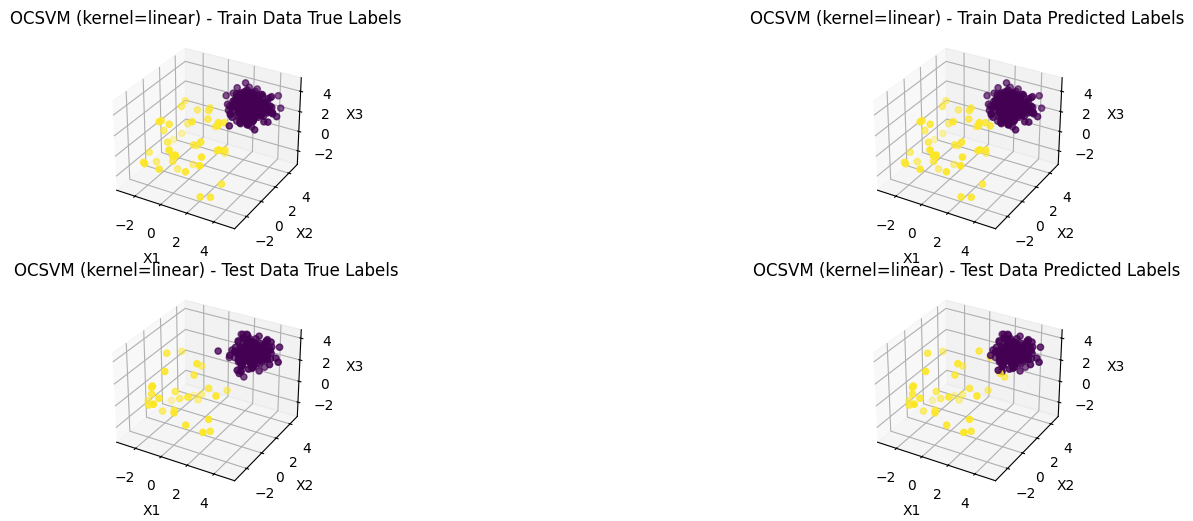

kernel=rbf, Balanced Accuracy: 1.0, ROC AUC: 1.0


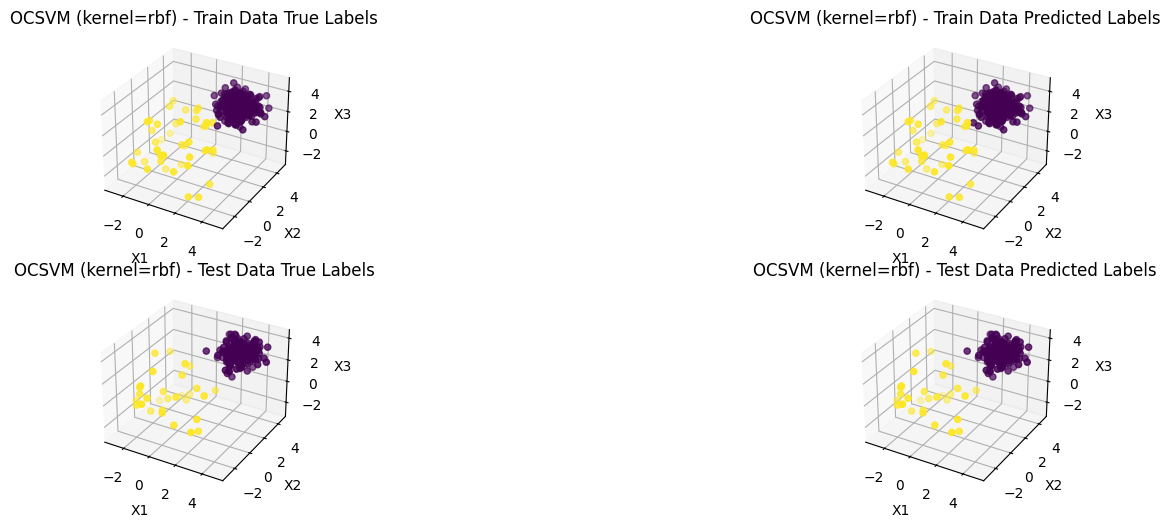

In [6]:
def ex1_2(X_train, Y_train, X_test, Y_test, kernel):
    contamination = 0.15

    ocsvm = OCSVM(kernel=kernel, contamination=contamination)

    ocsvm.fit(X_train)

    Y_train_pred = ocsvm.predict(X_train)

    Y_test_pred = ocsvm.predict(X_test)
    Y_test_scores = ocsvm.decision_function(X_test)

    balanced_accuracy = balanced_accuracy_score(Y_test, Y_test_pred)
    roc_auc = roc_auc_score(Y_test, Y_test_scores)

    print(f'kernel={kernel}, Balanced Accuracy: {balanced_accuracy}, ROC AUC: {roc_auc}')

    _, axes = plt.subplots(2, 2, figsize=(18, 6), subplot_kw={'projection': '3d'})
    axes = axes.flatten()

    axes[0].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=Y_train)
    axes[0].set_title(f'OCSVM (kernel={kernel}) - Train Data True Labels')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    axes[0].set_zlabel('X3')
    # axes[0].legend()

    axes[1].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=Y_train_pred)
    axes[1].set_title(f'OCSVM (kernel={kernel}) - Train Data Predicted Labels')
    axes[1].set_xlabel('X1')
    axes[1].set_ylabel('X2')
    axes[1].set_zlabel('X3')
    # axes[1].legend()

    axes[2].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=Y_test)
    axes[2].set_title(f'OCSVM (kernel={kernel}) - Test Data True Labels')
    axes[2].set_xlabel('X1')
    axes[2].set_ylabel('X2')
    axes[2].set_zlabel('X3')
    # axes[2].legend()

    axes[3].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=Y_test_pred)
    axes[3].set_title(f'OCSVM (kernel={kernel}) - Test Data Predicted Labels')
    axes[3].set_xlabel('X1')
    axes[3].set_ylabel('X2')
    axes[3].set_zlabel('X3')
    # axes[3].legend()

    plt.show()


ex1_2(X_train_ex1_1, Y_train_ex1_1, X_test_ex1_1, Y_test_ex1_1, kernel='linear')
ex1_2(X_train_ex1_1, Y_train_ex1_1, X_test_ex1_1, Y_test_ex1_1, kernel='rbf')

Epoch 1/100, Loss: 7.668320417404175
Epoch 2/100, Loss: 7.717457175254822
Epoch 3/100, Loss: 7.790512651205063
Epoch 4/100, Loss: 7.863350927829742
Epoch 5/100, Loss: 7.760145276784897
Epoch 6/100, Loss: 7.798793315887451
Epoch 7/100, Loss: 7.689575344324112
Epoch 8/100, Loss: 7.877225160598755
Epoch 9/100, Loss: 8.086770832538605
Epoch 10/100, Loss: 7.837638437747955
Epoch 11/100, Loss: 7.966777086257935
Epoch 12/100, Loss: 7.814468622207642
Epoch 13/100, Loss: 8.23292726278305
Epoch 14/100, Loss: 7.7112292647361755
Epoch 15/100, Loss: 7.915708601474762
Epoch 16/100, Loss: 7.935650110244751
Epoch 17/100, Loss: 7.84502500295639
Epoch 18/100, Loss: 7.723215579986572
Epoch 19/100, Loss: 7.8998881578445435
Epoch 20/100, Loss: 7.792842984199524
Epoch 21/100, Loss: 7.98762983083725
Epoch 22/100, Loss: 7.6815734803676605
Epoch 23/100, Loss: 7.722407579421997
Epoch 24/100, Loss: 7.7179548144340515
Epoch 25/100, Loss: 7.818989813327789
Epoch 26/100, Loss: 7.756518304347992
Epoch 27/100, Loss: 

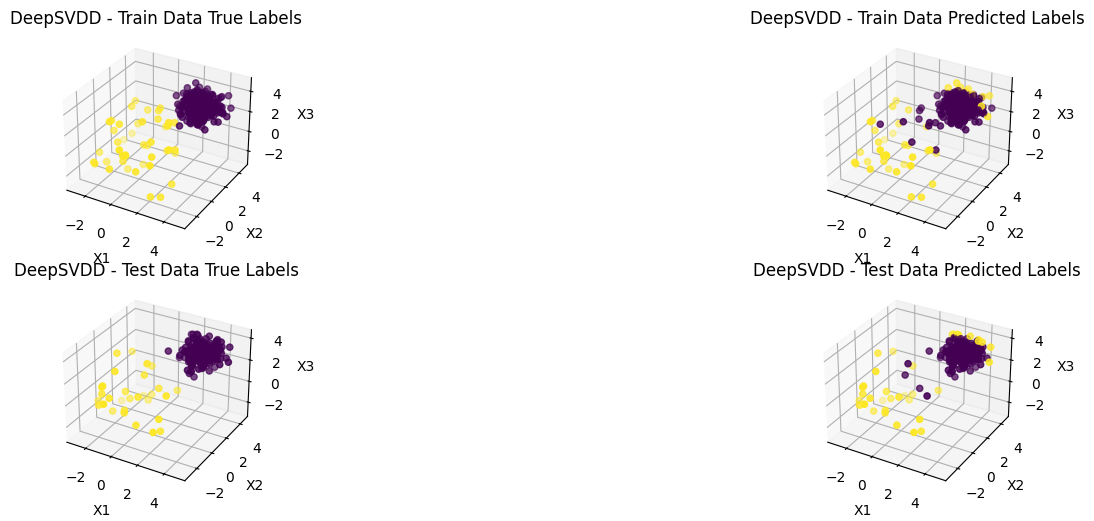

In [7]:
def ex1_5(X_train, Y_train, X_test, Y_test):
    contamination = 0.15

    deepsvdd = DeepSVDD(contamination=contamination, n_features=3)

    deepsvdd.fit(X_train)

    Y_train_pred = deepsvdd.predict(X_train)

    Y_test_pred = deepsvdd.predict(X_test)
    Y_test_scores = deepsvdd.decision_function(X_test)

    balanced_accuracy = balanced_accuracy_score(Y_test, Y_test_pred)
    roc_auc = roc_auc_score(Y_test, Y_test_scores)

    print(f'Balanced Accuracy: {balanced_accuracy}, ROC AUC: {roc_auc}')

    _, axes = plt.subplots(2, 2, figsize=(18, 6), subplot_kw={'projection': '3d'})
    axes = axes.flatten()

    axes[0].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=Y_train)
    axes[0].set_title(f'DeepSVDD - Train Data True Labels')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    axes[0].set_zlabel('X3')
    # axes[0].legend()

    axes[1].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=Y_train_pred)
    axes[1].set_title(f'DeepSVDD - Train Data Predicted Labels')
    axes[1].set_xlabel('X1')
    axes[1].set_ylabel('X2')
    axes[1].set_zlabel('X3')
    # axes[1].legend()

    axes[2].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=Y_test)
    axes[2].set_title(f'DeepSVDD - Test Data True Labels')
    axes[2].set_xlabel('X1')
    axes[2].set_ylabel('X2')
    axes[2].set_zlabel('X3')
    # axes[2].legend()

    axes[3].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=Y_test_pred)
    axes[3].set_title(f'DeepSVDD - Test Data Predicted Labels')
    axes[3].set_xlabel('X1')
    axes[3].set_ylabel('X2')
    axes[3].set_zlabel('X3')
    # axes[3].legend()

    plt.show()


ex1_5(X_train_ex1_1, Y_train_ex1_1, X_test_ex1_1, Y_test_ex1_1)

### Exercise 2

In [8]:
def ex2_1():
    cardio_mat = loadmat('cardio-1.mat')

    X_cardio_mat = cardio_mat['X']
    Y_cardio_mat = cardio_mat['y']

    print(f'Loaded cardio-1.mat dataset:')
    print(f'X shape: {X_cardio_mat.shape}')
    print(f'Y shape: {Y_cardio_mat.shape}')

    print(f'Y_cardio_mat values: {set(Y_cardio_mat.flatten().tolist())}')
    Y_cardio_mat = -2.0 * (Y_cardio_mat - 0.5) # Conversie de la PyOD la SkLearn
    print(f'Y_cardio_mat values: {set(Y_cardio_mat.flatten().tolist())}')

    train_percentage = 0.4

    X_train, X_test, Y_train, Y_test = train_test_split(X_cardio_mat, Y_cardio_mat,
        train_size=train_percentage, shuffle=True, random_state=23)
    
    return X_train, Y_train, X_test, Y_test


X_train_ex2_1, Y_train_ex2_1, X_test_ex2_1, Y_test_ex2_1 = ex2_1()

Loaded cardio-1.mat dataset:
X shape: (1831, 21)
Y shape: (1831, 1)
Y_cardio_mat values: {0.0, 1.0}
Y_cardio_mat values: {1.0, -1.0}


In [9]:
def ex2_2(X_train, X_test, Y_test):
    parameters_map = {
        'kernels': ['linear', 'rbf', 'poly', 'sigmoid'],
        'gammas': ['scale', 'auto', 0.01, 0.1, 1.0, 10.0],
        'nius': [0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.5, 0.75]
    }

    best_model_balanced_accuracy = None
    best_model_parameters_balanced_accuracy = None
    best_model_roc_auc = None
    best_model_parameters_roc_auc = None

    best_balanced_accuracy = -1.0
    best_roc_auc = -1.0

    for kernel in parameters_map['kernels']:
        for gamma in parameters_map['gammas']:
            for niu in parameters_map['nius']:
                if kernel == 'linear':
                    ocsvm = OneClassSVM(kernel=kernel, nu=niu)
                else:
                    ocsvm = OneClassSVM(kernel=kernel, gamma=gamma, nu=niu)

                ocsvm.fit(X_train)

                Y_test_pred = ocsvm.predict(X_test)
                Y_test_scores = ocsvm.decision_function(X_test)

                balanced_accuracy = balanced_accuracy_score(Y_test, Y_test_pred)
                roc_auc = roc_auc_score(Y_test, Y_test_scores)

                print(f'kernel={kernel} gamma={gamma} niu={niu} balanced_accuracy={balanced_accuracy} roc_auc={roc_auc}')

                if balanced_accuracy > best_balanced_accuracy:
                    best_balanced_accuracy = balanced_accuracy
                    best_model_balanced_accuracy = ocsvm
                    if kernel == 'linear':
                        best_model_parameters_balanced_accuracy = {'kernel':kernel, 'niu':niu}
                    else:
                        best_model_parameters_balanced_accuracy = {'kernel':kernel, 'gamma':gamma, 'niu':niu}

                if roc_auc > best_roc_auc:
                    best_roc_auc = roc_auc
                    best_model_roc_auc = ocsvm
                    if kernel == 'linear':
                        best_model_parameters_roc_auc = {'kernel':kernel, 'niu':niu}
                    else:
                        best_model_parameters_roc_auc = {'kernel':kernel, 'gamma':gamma, 'niu':niu}

    print(f'Best Model by Balanced Accuracy: {best_model_parameters_balanced_accuracy} with Balanced Accuracy: {best_balanced_accuracy}')
    print(f'Best Model by ROC AUC: {best_model_parameters_roc_auc} with ROC AUC: {best_roc_auc}')


ex2_2(X_train_ex2_1, X_test_ex2_1, Y_test_ex2_1)

kernel=linear gamma=scale niu=0.01 balanced_accuracy=0.5083349439505218 roc_auc=0.402676845767298
kernel=linear gamma=scale niu=0.05 balanced_accuracy=0.6009180517974488 roc_auc=0.5569771936606107
kernel=linear gamma=scale niu=0.1 balanced_accuracy=0.25181194433706994 roc_auc=0.12426555856204097
kernel=linear gamma=scale niu=0.2 balanced_accuracy=0.2674429841515269 roc_auc=0.22721298801700812
kernel=linear gamma=scale niu=0.25 balanced_accuracy=0.3135919984538075 roc_auc=0.21757827599536142
kernel=linear gamma=scale niu=0.3 balanced_accuracy=0.396477580208736 roc_auc=0.36115191341321995
kernel=linear gamma=scale niu=0.5 balanced_accuracy=0.26843351372245844 roc_auc=0.2170660997294163
kernel=linear gamma=scale niu=0.75 balanced_accuracy=0.42211538461538467 roc_auc=0.345873598763046
kernel=linear gamma=auto niu=0.01 balanced_accuracy=0.5083349439505218 roc_auc=0.402676845767298
kernel=linear gamma=auto niu=0.05 balanced_accuracy=0.6009180517974488 roc_auc=0.5569771936606107
kernel=linear

In [10]:
def ex2_3(X_train, Y_train, X_test, Y_test):

    grid_search_cv = GridSearchCV(estimator=OneClassSVM(),
                                  param_grid={
                                    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                                    'gamma': ['scale', 'auto', 0.01, 0.1, 1.0, 10.0],
                                    'nu': [0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.5, 0.75]
                                  },
                                  cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=23),
                                  scoring='balanced_accuracy')
    
    grid_search_cv.fit(X_train, Y_train)

    best_model = grid_search_cv.best_estimator_
    best_parameters = grid_search_cv.best_params_

    Y_test_pred = best_model.predict(X_test)
    Y_test_scores = best_model.decision_function(X_test)

    balanced_accuracy = balanced_accuracy_score(Y_test, Y_test_pred)
    roc_auc = roc_auc_score(Y_test, Y_test_scores)

    print(f'Best Model by GridSearchCV: {best_parameters} with Balanced Accuracy: {balanced_accuracy} and ROC AUC: {roc_auc}')


ex2_3(X_train_ex2_1, Y_train_ex2_1, X_test_ex2_1, Y_test_ex2_1)    

Best Model by GridSearchCV: {'gamma': 0.01, 'kernel': 'rbf', 'nu': 0.25} with Balanced Accuracy: 0.8865143022806339 and ROC AUC: 0.9272033243138771


In [11]:
def ex2_4(X_train, Y_train, X_test, Y_test):
    
    pipeline = Pipeline([
        ('standard_scaler', StandardScaler()),
        ('ocsvm', OneClassSVM())
    ])

    grid_search_cv = GridSearchCV(estimator=pipeline,
                                  param_grid={
                                    'ocsvm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                                    'ocsvm__gamma': ['scale', 'auto', 0.01, 0.1, 1.0, 10.0],
                                    'ocsvm__nu': [0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.5, 0.75]
                                  },
                                  cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=23),
                                  scoring='balanced_accuracy')
    
    grid_search_cv.fit(X_train, Y_train)

    best_model = grid_search_cv.best_estimator_
    best_parameters = grid_search_cv.best_params_

    Y_test_pred = best_model.predict(X_test)
    Y_test_scores = best_model.decision_function(X_test)

    balanced_accuracy = balanced_accuracy_score(Y_test, Y_test_pred)
    roc_auc = roc_auc_score(Y_test, Y_test_scores)

    print(f'Best Model by GridSearchCV: {best_parameters} with Balanced Accuracy: {balanced_accuracy} and ROC AUC: {roc_auc}')


ex2_4(X_train_ex2_1, Y_train_ex2_1, X_test_ex2_1, Y_test_ex2_1)    

Best Model by GridSearchCV: {'ocsvm__gamma': 0.01, 'ocsvm__kernel': 'rbf', 'ocsvm__nu': 0.25} with Balanced Accuracy: 0.8817066099729416 and ROC AUC: 0.9252126014688828


### Exercise 3

In [12]:
def ex3_1():
    shuttle_mat = loadmat('shuttle-1.mat')

    X_shuttle_mat = shuttle_mat['X']
    Y_shuttle_mat = shuttle_mat['y']

    print(f'Loaded shuttle-1.mat dataset:')
    print(f'X shape: {X_shuttle_mat.shape}')
    print(f'Y shape: {Y_shuttle_mat.shape}')

    print(f'Y_shuttle_mat values: {set(Y_shuttle_mat.flatten().tolist())}')

    test_percentage = 0.5

    X_train, X_test, Y_train, Y_test = train_test_split(X_shuttle_mat, Y_shuttle_mat,
        test_size=test_percentage, shuffle=True, random_state=23)
    
    normalizer = Normalizer()
    normalizer.fit(X_train)
    X_train = normalizer.transform(X_train)
    X_test = normalizer.transform(X_test)
    
    return X_train, Y_train, X_test, Y_test


X_train_ex3_1, Y_train_ex3_1, X_test_ex3_1, Y_test_ex3_1 = ex3_1()

Loaded shuttle-1.mat dataset:
X shape: (49097, 9)
Y shape: (49097, 1)
Y_shuttle_mat values: {0, 1}


In [ ]:
def ex3_2(X_train, Y_train, X_test, Y_test, model):
    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    Y_train_scores = model.decision_function(X_train)

    Y_test_pred = model.predict(X_test)
    Y_test_scores = model.decision_function(X_test)

    balanced_accuracy_train = balanced_accuracy_score(Y_train, Y_train_pred)
    balanced_accuracy_test = balanced_accuracy_score(Y_test, Y_test_pred)

    roc_auc_train = roc_auc_score(Y_train, Y_train_scores)
    roc_auc_test = roc_auc_score(Y_test, Y_test_scores)

    print(f'Model: {model.__class__.__name__}')
    print(f'Train Balanced Accuracy: {balanced_accuracy_train} and Test Balanced Accuracy: {balanced_accuracy_test}')
    print(f'Train ROC AUC: {roc_auc_train} and Test ROC AUC: {roc_auc_test}')


ex3_2(X_train_ex3_1, Y_train_ex3_1, X_test_ex3_1, Y_test_ex3_1, OneClassSVM())
ex3_2(X_train_ex3_1, Y_train_ex3_1, X_test_ex3_1, Y_test_ex3_1, DeepSVDD(n_features=X_train_ex3_1.shape[1]))
ex3_2(X_train_ex3_1, Y_train_ex3_1, X_test_ex3_1, Y_test_ex3_1, DeepSVDD(n_features=X_train_ex3_1.shape[1], hidden_neurons=[32, 16, 32], epochs=16, batch_size=32, hidden_activation='relu'))
ex3_2(X_train_ex3_1, Y_train_ex3_1, X_test_ex3_1, Y_test_ex3_1, DeepSVDD(n_features=X_train_ex3_1.shape[1], hidden_neurons=[64, 32, 32], epochs=32, batch_size=64, hidden_activation='relu'))


Model: OneClassSVM
Train Balanced Accuracy: 0.0 and Test Balanced Accuracy: 0.0
Train ROC AUC: 0.010033812500167591 and Test ROC AUC: 0.008921704639257044
Epoch 1/100, Loss: 796.2669409513474
Epoch 2/100, Loss: 796.5530973672867
Epoch 3/100, Loss: 796.0900877565145
Epoch 4/100, Loss: 796.7275377810001
Epoch 5/100, Loss: 796.175549954176
Epoch 6/100, Loss: 796.7545654773712
Epoch 7/100, Loss: 796.5713159739971
Epoch 8/100, Loss: 796.1685757040977
Epoch 9/100, Loss: 796.0782495588064
Epoch 10/100, Loss: 796.1094946861267
Epoch 11/100, Loss: 797.1429357230663
Epoch 12/100, Loss: 796.9406830370426
Epoch 13/100, Loss: 796.1255083829165
Epoch 14/100, Loss: 798.036302536726
Epoch 15/100, Loss: 796.4391191005707
Epoch 16/100, Loss: 796.0536907911301
Epoch 17/100, Loss: 797.405553728342
Epoch 18/100, Loss: 796.8814308047295
Epoch 19/100, Loss: 796.2471993863583
Epoch 20/100, Loss: 797.3630868196487
Epoch 21/100, Loss: 796.3402201980352
Epoch 22/100, Loss: 796.3000304102898
Epoch 23/100, Loss: 7